<a href="https://colab.research.google.com/github/ssmito/dmeyf2026/blob/main/ensembles/z494_TareaHogar_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea para el Hogar 04

##  1. Big Picture

LightGBM es el algoritmo estado del arte para datasets estructurados.
<br> La Bayesian Optimization es el estado del arte para optimización de hiperparámetros
<br> Las soluciones a las tres competencias de la asignatura contendrán LightGBMs y Bayesian Optimizations
<br> LightGBM ha aumentado en forma no darwiniana sus hiperparámetros en los últimos ocho años; no todos los existentes son útiles.
<br> Es necesario lograr entender cuales son los hiperparámetros relevantes de LightGBM

## 2. Hiperparámetros del LightGBM

Los objetivos de esta tarea son:


*   Aumentar la rentabilidad de la campaña de marketing de retención proactiva de clientes.
*   Generar un mejor modelo optimizando sus hiperparámetros
*   Conceptual : investigar los mas relevantes hiperparámetros de LightGBM
*   Familiarizarse con la Bayesian Optimization, sus largos tiempos de corrida y opciones para reducirlos
*   Familiarizarse con el uso de máquinas virtuales de Google Colab
*   Ver un pipeline completo de optimización de hiperparámetros y puesta en producción

LightGBM cuenta con mas de 60 hiperparámetros, siendo posible utilizar 40 al mismo tiempo, aunque no razonable.
<br> La documentación oficial de los hiperparámetros de LightGBM es  https://lightgbm.readthedocs.io/en/latest/Parameters.html#core-parameters


Se lo alerta sobre que una Optimizacion Bayesiana lleva varias horas de corrida, y usted deberá correr VARIAS optimizaciones para descubrir cuales parámetros conviene optimizar.
<br> A pesar que la próxima clase es recien en viernes 01 de agosto, inicie la tarea con tiempo, aprenda a planificar estratégicamente sus corridas como un@ científ@  de datos.

Es necesario investigar cuales son los hiperparámetros de LightGBM que vale la pena optimizar en una Bayesian Optimization, ya que los realmente utiles son apenas un reducido subconjunto.
<br>Usted deberá investigar cuales son los hiperparámetros mas relevantes de LightGBM, su primer alternativa es preguntándole a su amigo con capacidades especiales ChatGPT o sus endogámicos familiares Claude, DeepSeek, Gemini, Grok, etc
<br> La segunda alternativa es la propia documentación de LightGBM  https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html


Adicionalmente podra buscar información como la que proveen esta diminuta muestra aleatoria de artículos ligeros:
*  https://medium.com/@sarahzouinina/a-deep-dive-into-lightgbm-how-to-choose-and-tune-parameters-7c584945842e
*  https://www.kaggle.com/code/somang1418/tuning-hyperparameters-under-10-minutes-lgbm
*  https://towardsdatascience.com/beginners-guide-to-the-must-know-lightgbm-hyperparameters-a0005a812702/


<br>  La muestra anterior se brinda a modo de ejemplo, usted deberá buscar muuuuchas  fuentes adicionales de información
<br> Tenga presente que LightGBM es el estado del arte en modelado predictivo para datasets estructurado, que son el 90% del trabajo del 95% de los Data Scientists en Argentina.

El desafío de esta tarea es:
* Qué hiperparparámetros conviene optimizar?  Las recomendaciones de los artículos ligeros es siempre sensata?  Sus autores realmente hicieron experimentos o son siemplemente escritores de entretenimiento carente de base científica?
* Elegidos los hiperparámetros, cual es el  <desde, hasta> que se debe utilizar en la Bayesian Optimization ?
* Realmente vale la pena optimizar 10 o 16 hiperparámetros al mismo tiempo ?  No resulta contraproducente una búsqueda en un espacio de tal alta dimensionalidad ?

#### 2.1  Seteo del ambiente en Google Colab

Esta parte se debe correr con el runtime en Python3
<br>Ir al menu, Runtime -> Change Runtime Type -> Runtime type ->  **Python 3**

Conectar la virtual machine donde esta corriendo Google Colab con el  Google Drive, para poder tener persistencia de archivos

In [1]:
# primero establecer el Runtime de Python 3
from google.colab import drive
drive.mount('/content/.drive')

Mounted at /content/.drive


Para correr la siguiente celda es fundamental en Arranque en Frio haber copiado el archivo kaggle.json al Google Drive, en la carpeta indicada en el instructivo

<br>los siguientes comando estan en shell script de Linux
*   Crear las carpetas en el Google Drive
*   "instalar" el archivo kaggle.json desde el Google Drive a la virtual machine para que pueda ser utilizado por la libreria  kaggle de Python
*   Bajar el  **dataset_pequeno**  al  Google Drive  y tambien al disco local de la virtual machine que esta corriendo Google Colab



In [2]:
%%shell

mkdir -p "/content/.drive/My Drive/dmeyf"
mkdir -p "/content/buckets"
ln -s "/content/.drive/My Drive/dmeyf" /content/buckets/b1


mkdir -p /content/buckets/b1/exp
mkdir -p /content/buckets/b1/datasets
mkdir -p /content/datasets



archivo_origen="https://storage.googleapis.com/open-courses/dmeyf2026-9c6f/competencia_01_crudo.csv"
archivo_destino="/content/datasets/competencia_01_crudo.csv"
archivo_destino_bucket="/content/buckets/b1/datasets/competencia_01_crudo.csv"

if ! test -f $archivo_destino_bucket; then
  wget  $archivo_origen  -O $archivo_destino_bucket
fi


if ! test -f $archivo_destino; then
  cp  $archivo_destino_bucket  $archivo_destino
fi


## Generacion de la clase_ternaria

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Tipe -> Runtime type -> R

In [1]:
require( "data.table" )

# leo el dataset
dataset <- fread("/content/datasets/competencia_01_crudo.csv" )

# calculo el periodo0 consecutivo
dsimple <- dataset[, list(
    "pos" = .I,
    numero_de_cliente,
    periodo0 = as.integer(foto_mes/100)*12 +  foto_mes%%100 ) ]


# ordeno
setorder( dsimple, numero_de_cliente, periodo0 )

# calculo topes
periodo_ultimo <- dsimple[, max(periodo0) ]
periodo_anteultimo <- periodo_ultimo - 1


# calculo los leads de orden 1 y 2
dsimple[, c("periodo1", "periodo2") :=
    shift(periodo0, n=1:2, fill=NA, type="lead"),  numero_de_cliente ]

# assign most common class values = "CONTINUA"
dsimple[ periodo0 < periodo_anteultimo, clase_ternaria := "CONTINUA" ]

# calculo BAJA+1
dsimple[ periodo0 < periodo_ultimo &
    ( is.na(periodo1) | periodo0 + 1 < periodo1 ),
    clase_ternaria := "BAJA+1" ]

# calculo BAJA+2
dsimple[ periodo0 < periodo_anteultimo & (periodo0+1 == periodo1 )
    & ( is.na(periodo2) | periodo0 + 2 < periodo2 ),
    clase_ternaria := "BAJA+2" ]


# pego el resultado en el dataset original y grabo
setorder( dsimple, pos )
dataset[, clase_ternaria := dsimple$clase_ternaria ]

fwrite( dataset,
    file =  "/content/datasets/competencia_01.csv.gz",
    sep = ","
)

Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%




In [2]:
setorder( dataset, foto_mes, clase_ternaria, numero_de_cliente)
dataset[, .N, list(foto_mes, clase_ternaria)]

foto_mes,clase_ternaria,N
<int>,<chr>,<int>
202103,BAJA+1,1019
202103,BAJA+2,960
202103,CONTINUA,160921
202104,BAJA+1,964
202104,BAJA+2,1139
202104,CONTINUA,161181
202105,BAJA+1,1143
202105,BAJA+2,870
202105,CONTINUA,161755


### 2.2 Optimizacion Hiperparámetros

Esta parte se debe correr con el runtime en lenguaje R Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

### 2.2.1 Inicio

limpio el ambiente de R

In [3]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Sat Sep 19 04:59:02 PM 2026"

In [4]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,741504,39.7,1473300,78.7,1473300,78.7
Vcells,1391539,10.7,170859661,1303.6,212615883,1622.2


### 2.2.2 Carga de Librerias

Esta parte lleva varios minutos la primera vez en Google Colab

In [5]:
# cargo las librerias que necesito
require("data.table")
require("parallel")

if(!require("R.utils")) install.packages("R.utils")
require("R.utils")

if( !require("primes") ) install.packages("primes")
require("primes")

if( !require("utils") ) install.packages("utils")
require("utils")

if( !require("rlist") ) install.packages("rlist")
require("rlist")

if( !require("yaml")) install.packages("yaml")
require("yaml")

if( !require("lightgbm") ) install.packages("lightgbm")
require("lightgbm")

if( !require("DiceKriging") ) install.packages("DiceKriging")
require("DiceKriging")

if( !require("mlrMBO") ) install.packages("mlrMBO")
require("mlrMBO")

Loading required package: parallel

Loading required package: R.utils

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘R.utils’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘R.oo’, ‘R.methodsS3’


Loading required package: R.utils

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


At

### 2.2.3 Definicion de Parametros

aqui debe cargar SU semilla primigenia
<br>recuerde cambiar el numero de experimento en cada corrida nueva

In [79]:
PARAM <- list()
PARAM$experimento <- 4999
PARAM$semilla_primigenia <- 230047


In [80]:
# training y future
PARAM$train <- c(202104)
PARAM$train_final <- c(202104)
PARAM$future <- c(202106)
PARAM$semilla_kaggle <- 314159
PARAM$cortes <- seq(4000, 19000, by= 500)

In [81]:
# un undersampling de 0.1  toma solo el 10% de los CONTINUA
# undersampling de 1.0  implica tomar TODOS los datos

PARAM$trainingstrategy$undersampling <- 0.1

In [82]:
# Parametros LightGBM

PARAM$hyperparametertuning$xval_folds <- 5

# parametros fijos del LightGBM que se pisaran con la parte variable de la BO
PARAM$lgbm$param_fijos <-  list(
  boosting= "gbdt", # puede ir  dart  , ni pruebe random_forest
  objective= "binary",
  metric= "auc",
  first_metric_only= FALSE,
  boost_from_average= TRUE,
  feature_pre_filter= FALSE,
  force_row_wise= TRUE, # para reducir warnings
  verbosity= -100,

  seed= PARAM$semilla_primigenia,

  max_depth= -1L, # -1 significa no limitar,  por ahora lo dejo fijo
  min_gain_to_split= 0, # min_gain_to_split >= 0
  min_sum_hessian_in_leaf= 0.0067274, #  min_sum_hessian_in_leaf >= 0.0
  lambda_l1= 0.0, # lambda_l1 >= 0.0
  lambda_l2= 0.0, # lambda_l2 >= 0.0
  max_bin= 31L, # lo debo dejar fijo, no participa de la BO

  bagging_fraction= 1.0, # 0.0 < bagging_fraction <= 1.0
  pos_bagging_fraction= 1.0, # 0.0 < pos_bagging_fraction <= 1.0
  neg_bagging_fraction= 1.0, # 0.0 < neg_bagging_fraction <= 1.0
  is_unbalance= FALSE, #
  scale_pos_weight= 1.0, # scale_pos_weight > 0.0

  drop_rate= 0.1, # 0.0 < neg_bagging_fraction <= 1.0
  max_drop= 50, # <=0 means no limit
  skip_drop= 0.5, # 0.0 <= skip_drop <= 1.0
  extra_trees= FALSE,
  early_stopping = 0,

  num_iterations= 2505,
  learning_rate= 0.0020182,
  feature_fraction= 0.5707911,
  num_leaves= 61,
  min_data_in_leaf= 1840
)


Aqui se definen los hiperparámetros de LightGBM que participan de la Bayesian Optimization
<br> si es un numero entero debe ir  makeIntegerParam
<br> si es un numero real (con decimales) debe ir  makeNumericParam
<br> es muy importante leer cuales son un lower y upper  permitidos y ademas razonables

In [83]:
# Aqui se cargan los bordes de los hiperparametros de la BO
PARAM$hypeparametertuning$hs <- makeParamSet(
  makeIntegerParam("num_iterations", lower= 2450L, upper= 2550),
  makeNumericParam("learning_rate", lower= 0.002, upper= 0.0025),
  makeNumericParam("feature_fraction", lower= 0.56, upper= 0.6),
  makeIntegerParam("num_leaves", lower= 51L, upper= 71),
  makeIntegerParam("min_data_in_leaf", lower= 1740L, upper= 1940L)
)

A mayor cantidad de hiperparámetros, se debe aumentar las iteraciones de la Bayesian Optimization
<br> 30 es un valor muy tacaño, pero corre rápido
<br> deberia partir de 50, alcanzando los 100 si se dispone de tiempo

In [84]:
PARAM$hyperparametertuning$iteraciones <- 15 # iteraciones bayesianas

In [85]:
# particionar agrega una columna llamada fold a un dataset
#   que consiste en una particion estratificada segun agrupa
# particionar( data=dataset, division=c(70,30),
#  agrupa=clase_ternaria, seed=semilla)   crea una particion 70, 30

particionar <- function(data, division, agrupa= "", campo= "fold", start= 1, seed= NA) {
  if (!is.na(seed)) set.seed(seed, "L'Ecuyer-CMRG")

  bloque <- unlist(mapply(
    function(x, y) {rep(y, x)},division, seq(from= start, length.out= length(division))))

  data[, (campo) := sample(rep(bloque,ceiling(.N / length(bloque))))[1:.N],by= agrupa]
}

In [86]:
# iniciliazo el dataset de realidad, para medir ganancia
realidad_inicializar <- function( pfuture, pparam) {

  # datos para verificar la ganancia
  drealidad <- pfuture[, list(numero_de_cliente, foto_mes, clase_ternaria)]

  particionar(drealidad,
    division= c(3, 7),
    agrupa= "clase_ternaria",
    seed= PARAM$semilla_kaggle
  )

  return( drealidad )
}

In [87]:
# evaluo ganancia en los datos de la realidad

realidad_evaluar <- function( prealidad, pprediccion) {

  prealidad[ pprediccion,
    on= c("numero_de_cliente", "foto_mes"),
    predicted:= i.Predicted
  ]

  tbl <- prealidad[, list("qty"=.N), list(fold, predicted, clase_ternaria)]

  res <- list()
  res$public  <- tbl[fold==1 & predicted==1L, sum(qty*ifelse(clase_ternaria=="BAJA+2", 1072500, -27500))]/0.3
  res$private <- tbl[fold==2 & predicted==1L, sum(qty*ifelse(clase_ternaria=="BAJA+2", 1072500, -27500))]/0.7
  res$total <- tbl[predicted==1L, sum(qty*ifelse(clase_ternaria=="BAJA+2", 1072500, -27500))]

  prealidad[, predicted:=NULL]
  return( res )
}

### 2.2.4  Preprocesamiento

In [88]:
# carpeta de trabajo

setwd("/content/buckets/b1/exp")
experimento_folder <- paste0("HT", PARAM$experimento)
dir.create(experimento_folder, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento_folder ))

In [89]:
# lectura del dataset
dataset <- fread("/content/datasets/competencia_01.csv.gz", stringsAsFactors= TRUE)

In [90]:
dataset_train <- dataset[foto_mes %in% PARAM$train]

In [91]:
# paso la clase a binaria que tome valores {0,1}  enteros
#  BAJA+1 y BAJA+2  son  1,   CONTINUA es 0
#  a partir de ahora ya NO puedo cortar  por prob(BAJA+2) > 1/40

dataset_train[,
  clase01 := ifelse(clase_ternaria %in% c("BAJA+2","BAJA+1"), 1L, 0L)
]

In [92]:
# defino los datos que forma parte del training
# aqui se hace el undersampling de los CONTINUA
# notar que para esto utilizo la SEGUNDA semilla

set.seed(PARAM$semilla_primigenia, kind = "L'Ecuyer-CMRG")
dataset_train[, azar := runif(nrow(dataset_train))]
dataset_train[, training := 0L]

dataset_train[
  foto_mes %in%  PARAM$train &
    (azar <= PARAM$trainingstrategy$undersampling | clase_ternaria %in% c("BAJA+1", "BAJA+2")),
  training := 1L
]

In [93]:
# los campos que se van a utilizar

campos_buenos <- setdiff(
  colnames(dataset_train),
  c("clase_ternaria", "clase01", "azar", "training")
)

In [94]:
# dejo los datos en el formato que necesita LightGBM

dtrain <- lgb.Dataset(
  data= data.matrix(dataset_train[training == 1L, campos_buenos, with= FALSE]),
  label= dataset_train[training == 1L, clase01],
  free_raw_data= FALSE
)

nrow(dtrain)
ncol(dtrain)

[1] 18336

[1] 154

2.2.5 Configuracion Bayesian Optimization

In [95]:
# En el argumento x llegan los parmaetros de la bayesiana
#  devuelve la AUC en cross validation del modelo entrenado

EstimarGanancia_AUC_lightgbm <- function(x) {

  # x pisa (o agrega) a param_fijos
  param_completo <- modifyList(PARAM$lgbm$param_fijos, x)

  # entreno LightGBM
  modelocv <- lgb.cv(
    data= dtrain,
    nfold= PARAM$hyperparametertuning$xval_folds,
    stratified= TRUE,
    param= param_completo
  )

  # obtengo la ganancia
  AUC <- modelocv$best_score

  # hago espacio en la memoria
  rm(modelocv)
  gc(full= TRUE, verbose= FALSE)

  message(format(Sys.time(), "%a %b %d %X %Y"), " AUC ", AUC)

  return(AUC)
}

In [96]:
# Aqui comienza la configuracion de la Bayesian Optimization

# en este archivo quedan la evolucion binaria de la BO
kbayesiana <- "bayesiana.RDATA"

funcion_optimizar <- EstimarGanancia_AUC_lightgbm # la funcion que voy a maximizar

configureMlr(show.learner.output= FALSE)

# configuro la busqueda bayesiana,  los hiperparametros que se van a optimizar
# por favor, no desesperarse por lo complejo

obj.fun <- makeSingleObjectiveFunction(
  fn= funcion_optimizar, # la funcion que voy a maximizar
  minimize= FALSE, # estoy Maximizando la ganancia
  noisy= TRUE,
  par.set= PARAM$hypeparametertuning$hs, # definido al comienzo del programa
  has.simple.signature= FALSE # paso los parametros en una lista
)

# cada 600 segundos guardo el resultado intermedio
ctrl <- makeMBOControl(
  save.on.disk.at.time= 600, # se graba cada 600 segundos
  save.file.path= kbayesiana
) # se graba cada 600 segundos

# indico la cantidad de iteraciones que va a tener la Bayesian Optimization
ctrl <- setMBOControlTermination(
  ctrl,
  iters= PARAM$hyperparametertuning$iteraciones
) # cantidad de iteraciones

# defino el método estandar para la creacion de los puntos iniciales,
# los "No Inteligentes"
ctrl <- setMBOControlInfill(ctrl, crit= makeMBOInfillCritEI())

# establezco la funcion que busca el maximo
surr.km <- makeLearner(
  "regr.km",
  predict.type= "se",
  covtype= "matern3_2",
  control= list(trace= TRUE)
)


2.2.6 Corrida Bayesian Optimization

In [97]:

# inicio la optimizacion bayesiana, retomando si ya existe
# es la celda mas lenta de todo el notebook

if (!file.exists(kbayesiana)) {
  bayesiana_salida <- mbo(obj.fun, learner= surr.km, control= ctrl)
} else {
  bayesiana_salida <- mboContinue(kbayesiana) # retomo en caso que ya exista
}

Computing y column(s) for design. Not provided.

Sat Sep 19 05:46:52 PM 2026 AUC 0.919365716665714

Sat Sep 19 05:48:22 PM 2026 AUC 0.918399745034617

Sat Sep 19 05:49:55 PM 2026 AUC 0.917664440988374

Sat Sep 19 05:51:22 PM 2026 AUC 0.917905567923919

Sat Sep 19 05:52:48 PM 2026 AUC 0.918613426009225

Sat Sep 19 05:54:05 PM 2026 AUC 0.917629375375192

Sat Sep 19 05:55:31 PM 2026 AUC 0.917390765905379

Sat Sep 19 05:57:01 PM 2026 AUC 0.917103158766113

Sat Sep 19 05:58:29 PM 2026 AUC 0.918402089174862

Sat Sep 19 05:59:49 PM 2026 AUC 0.918632431793053

Sat Sep 19 06:01:03 PM 2026 AUC 0.917358033499068

Sat Sep 19 06:02:25 PM 2026 AUC 0.917771825920016

Sat Sep 19 06:03:59 PM 2026 AUC 0.918802542853078

Sat Sep 19 06:05:25 PM 2026 AUC 0.918138884093661

Sat Sep 19 06:06:45 PM 2026 AUC 0.918538007551586

Sat Sep 19 06:07:59 PM 2026 AUC 0.916852421284198

Sat Sep 19 06:09:38 PM 2026 AUC 0.918687449561176

Sat Sep 19 06:11:12 PM 2026 AUC 0.918688837743874

Sat Sep 19 06:12:28 PM 2026 AUC 0

In [98]:

tb_bayesiana <- as.data.table(bayesiana_salida$opt.path)
colnames( tb_bayesiana)

[1] "num_iterations"   "learning_rate"    "feature_fraction" "num_leaves"      
 [5] "min_data_in_leaf" "y"                "dob"              "eol"             
 [9] "error.message"    "exec.time"        "ei"               "error.model"     
[13] "train.time"       "prop.type"        "propose.time"     "se"              
[17] "mean"

In [99]:
# almaceno los resultados de la Bayesian Optimization
# y capturo los mejores hiperparametros encontrados

tb_bayesiana <- as.data.table(bayesiana_salida$opt.path)

tb_bayesiana[, iter := .I]

# ordeno en forma descendente por AUC = y
setorder(tb_bayesiana, -y)

# grabo para eventualmente poder utilizarlos en OTRA corrida
fwrite( tb_bayesiana,
  file= "BO_log.txt",
  sep= "\t"
)

# los mejores hiperparámetros son los que quedaron en el registro 1 de la tabla
PARAM$out$lgbm$mejores_hiperparametros <- tb_bayesiana[
  1, # el primero es el de mejor AUC
  setdiff(colnames(tb_bayesiana),
    c("y","dob","eol","error.message","exec.time","ei","error.model",
      "train.time","prop.type","propose.time","se","mean","iter")),
  with= FALSE
]


PARAM$out$lgbm$y <- tb_bayesiana[1, y]


In [100]:
write_yaml( PARAM, file="PARAM.yml")

In [101]:
print(PARAM$out$lgbm$mejores_hiperparametros)
print(PARAM$out$lgbm$y)

   num_iterations learning_rate feature_fraction num_leaves min_data_in_leaf
            <int>         <num>            <num>      <int>            <int>
1:           2515   0.002475776         0.579179         66             1794
[1] 0.9196336


## 2.3  Produccion

### Final Training
Construyo el modelo final, que es uno solo, no hace ningun tipo de particion < training, validation, testing>]

In [102]:
setwd("/content/buckets/b1/exp")
experimento <- paste0("exp", PARAM$experimento)
dir.create(experimento, showWarnings= FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento ))

#### Final Training Dataset

Aqui esta la gran decision de en qué meses hago el Final Training
<br> debo utilizar los mejores hiperparámetros que encontré en la  optimización bayesiana

In [103]:
# clase01
dataset[, clase01 := ifelse(clase_ternaria %in% c("BAJA+1", "BAJA+2"), 1L, 0L)]

In [104]:
dataset_train <- dataset[foto_mes %in% PARAM$train_final]
dataset_train[,.N,clase_ternaria]

clase_ternaria,N
<fct>,<int>
CONTINUA,161181
BAJA+2,1139
BAJA+1,964


In [105]:
# dejo los datos en el formato que necesita LightGBM

dtrain_final <- lgb.Dataset(
  data= data.matrix(dataset_train[, campos_buenos, with= FALSE]),
  label= dataset_train[, clase01]
)

#### Final Training Hyperparameters

In [106]:
param_final <- modifyList(PARAM$lgbm$param_fijos,
  PARAM$out$lgbm$mejores_hiperparametros)

param_final

$boosting
[1] "gbdt"

$objective
[1] "binary"

$metric
[1] "auc"

$first_metric_only
[1] FALSE

$boost_from_average
[1] TRUE

$feature_pre_filter
[1] FALSE

$force_row_wise
[1] TRUE

$verbosity
[1] -100

$seed
[1] 230047

$max_depth
[1] -1

$min_gain_to_split
[1] 0

$min_sum_hessian_in_leaf
[1] 0.0067274

$lambda_l1
[1] 0

$lambda_l2
[1] 0

$max_bin
[1] 31

$bagging_fraction
[1] 1

$pos_bagging_fraction
[1] 1

$neg_bagging_fraction
[1] 1

$is_unbalance
[1] FALSE

$scale_pos_weight
[1] 1

$drop_rate
[1] 0.1

$max_drop
[1] 50

$skip_drop
[1] 0.5

$extra_trees
[1] FALSE

$early_stopping
[1] 0

$num_iterations
[1] 2515

$learning_rate
[1] 0.002475776

$feature_fraction
[1] 0.579179

$num_leaves
[1] 66

$min_data_in_leaf
[1] 1794

#### Training
Genero el modelo final, siempre sobre TODOS los datos de  final_train, sin hacer ningun tipo de undersampling de la clase mayoritaria y mucho menos cross validation.

In [107]:
# este punto es muy SUTIL  y será revisado en la Clase 05

param_normalizado <- copy(param_final)
param_normalizado$min_data_in_leaf <-  round(param_final$min_data_in_leaf / PARAM$trainingstrategy$undersampling)

In [108]:
# entreno LightGBM

modelo_final <- lgb.train(
  data= dtrain_final,
  param= param_normalizado
)

In [109]:
# ahora imprimo la importancia de variables

tb_importancia <- as.data.table(lgb.importance(modelo_final))
archivo_importancia <- "impo.txt"

fwrite(tb_importancia,
  file= archivo_importancia,
  sep= "\t"
)

In [110]:
# grabo a disco el modelo en un formato para seres humanos ... ponele ...
lgb.save(modelo_final, "modelo.txt" )

### Scoring

Aplico el modelo final a los datos del futuro

In [111]:
# aplico el modelo a los datos sin clase
dfuture <- dataset[foto_mes %in% PARAM$future]

# aplico el modelo a los datos nuevos
prediccion <- predict(
  modelo_final,
  data.matrix(dfuture[, campos_buenos, with= FALSE])
)

#### Tabla Prediccion

In [112]:
# tabla de prediccion
tb_prediccion <- dfuture[, list(numero_de_cliente, foto_mes,clase_ternaria)]
tb_prediccion[, prob := prediccion ]

# grabo las probabilidad del modelo
fwrite(tb_prediccion[,list(numero_de_cliente,foto_mes,prob)],
  file= "prediccion.txt",
  sep= "\t"
)

In [113]:
# Dibujo la curva de ganancia acumulada
setorder(tb_prediccion,-prob)

tb_prediccion[, gan := ifelse(clase_ternaria == "BAJA+2", 1072500, -27500)]
tb_prediccion[, ganancia_acumulada := cumsum(gan)]
tb_prediccion[, pos := sequence(.N)]

In [114]:
tb_prediccion |> head()

numero_de_cliente,foto_mes,clase_ternaria,prob,gan,ganancia_acumulada,pos
<dbl>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<int>
55228276,202106,BAJA+1,0.4170096,-27500,-27500,1
35218889,202106,CONTINUA,0.4153111,-27500,-55000,2
53724476,202106,CONTINUA,0.4130287,-27500,-82500,3
71765174,202106,CONTINUA,0.4130287,-27500,-110000,4
59424738,202106,CONTINUA,0.4128615,-27500,-137500,5
71190513,202106,CONTINUA,0.4122213,-27500,-165000,6


In [115]:
# defino hasta donde muestra el grafico
amostrar <- 30000

In [116]:
require("ggplot2")

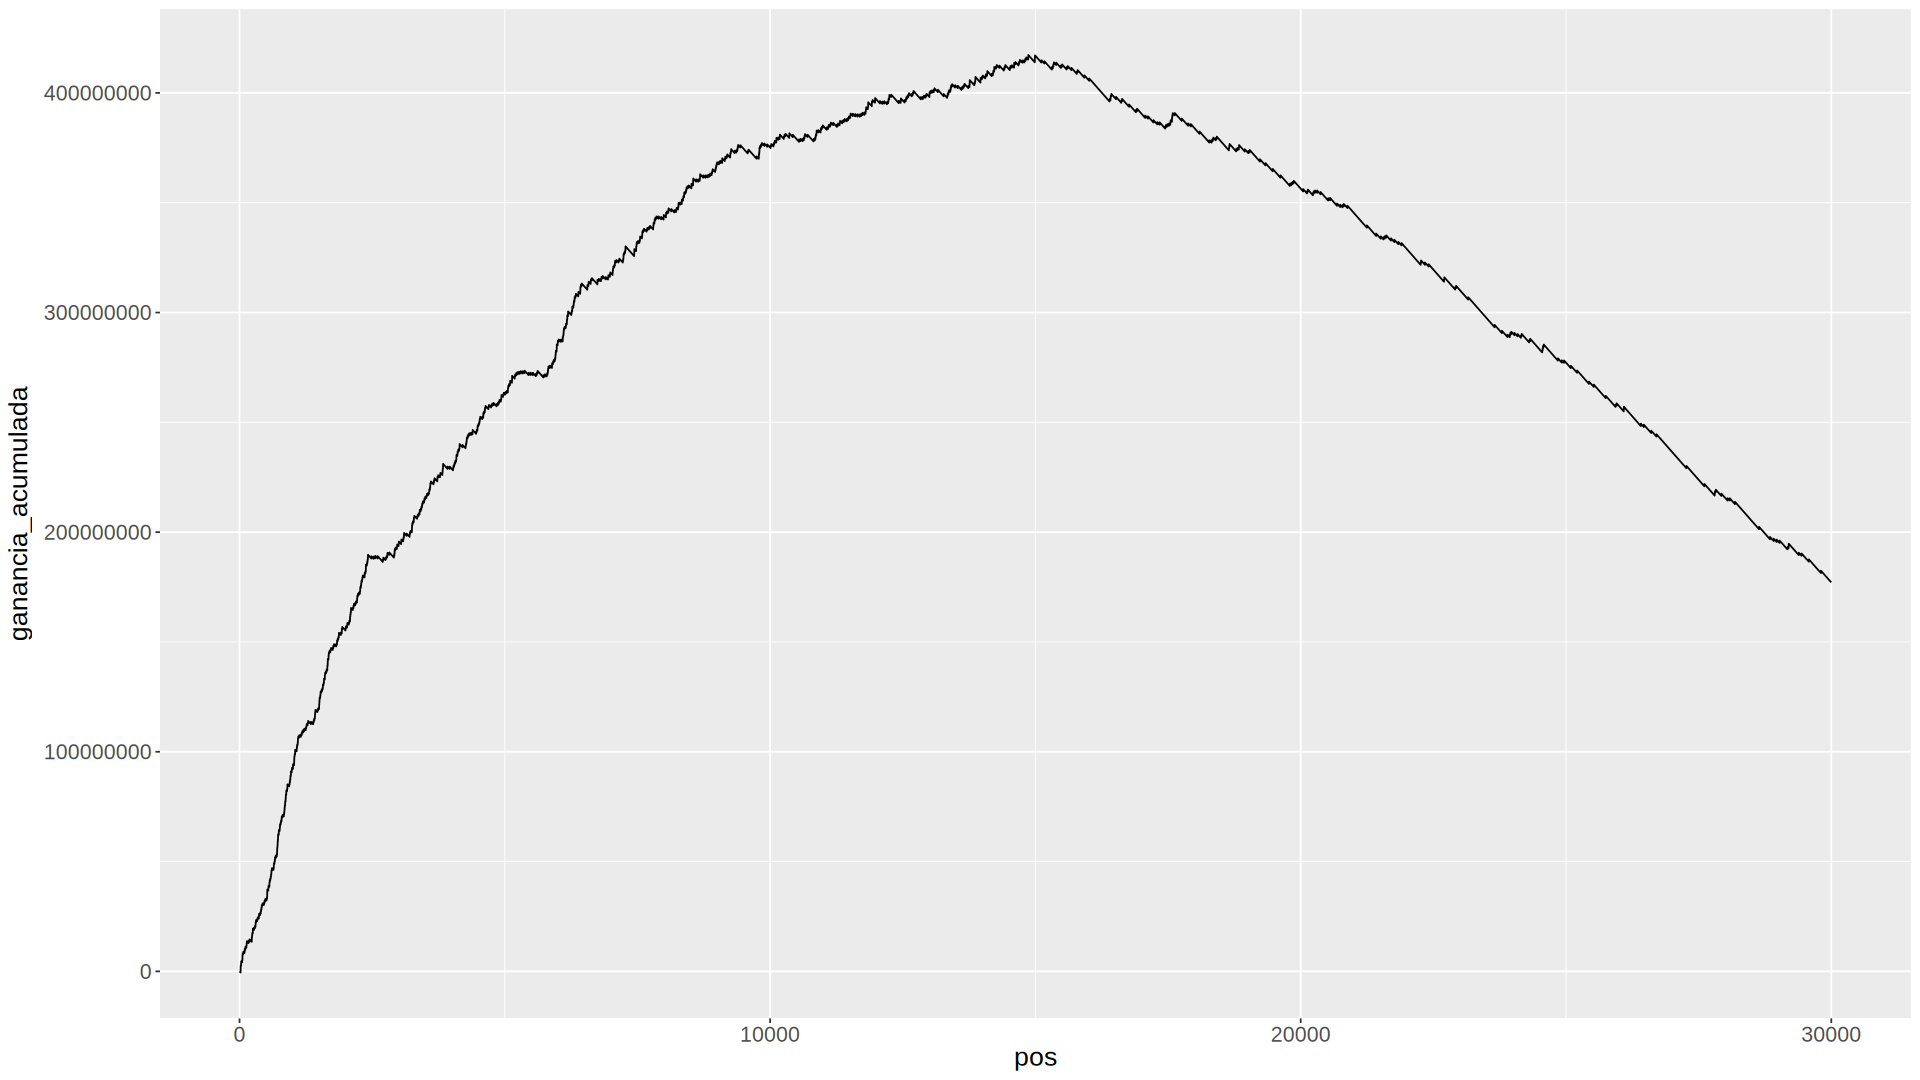

In [117]:
# observamos la curva de ganancia
gra <- ggplot(
           data= tb_prediccion[pos <= amostrar],
           aes( x= pos, y= ganancia_acumulada)
             ) + geom_line()

gra <- gra + theme(text = element_text(size = 16))

options(repr.plot.width=16, repr.plot.height=9)
print( gra )

Revisamos ganancia bajo distintos cortes

In [118]:
# inicilizo el dataset  drealidad
drealidad <- realidad_inicializar( dfuture, PARAM)

In [119]:
PARAM$cortes

[1]  4000  4500  5000  5500  6000  6500  7000  7500  8000  8500  9000  9500
[13] 10000 10500 11000 11500 12000 12500 13000 13500 14000 14500 15000 15500
[25] 16000 16500 17000 17500 18000 18500 19000

In [120]:
# genero archivos con los  "envios" mejores

# ordeno por probabilidad descendente
setorder(tb_prediccion, -prob)

for (envios in PARAM$cortes) {

  tb_prediccion[, Predicted := 0L] # seteo inicial a 0
  tb_prediccion[1:envios, Predicted := 1L] # marco los primeros

  res <- realidad_evaluar( drealidad, tb_prediccion)

  options(scipen = 999)
  cat( "Envios=", envios, "\t",
    " TOTAL=", res$total,
    "  Public=", res$public,
    " Private=", res$private,
    "\n",
    sep= ""
  )

}

Envios=4000	 TOTAL=228800000  Public=249241667 Private=220039286
Envios=4500	 TOTAL=249150000  Public=260058333 Private=244475000
Envios=5000	 TOTAL=262900000  Public=260791667 Private=263803571
Envios=5500	 TOTAL=272250000  Public=265283333 Private=275235714
Envios=6000	 TOTAL=287100000  Public=267666667 Private=295428571
Envios=6500	 TOTAL=311850000  Public=288475000 Private=321867857
Envios=7000	 TOTAL=317900000  Public=298191667 Private=326346429
Envios=7500	 TOTAL=331650000  Public=328350000 Private=333064286
Envios=8000	 TOTAL=344300000  Public=347966667 Private=342728571
Envios=8500	 TOTAL=356950000  Public=355941667 Private=357382143
Envios=9000	 TOTAL=367400000  Public=379225000 Private=362332143
Envios=9500	 TOTAL=374550000  Public=377391667 Private=373332143
Envios=10000	 TOTAL=375100000  Public=378491667 Private=373646429
Envios=10500	 TOTAL=378950000  Public=376383333 Private=380050000
Envios=11000	 TOTAL=385000000  Public=395358333 Private=380560714
Envios=11500	 TOTAL=38

In [121]:
write_yaml( PARAM, file="PARAM.yml")

In [122]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Sat Sep 19 06:39:26 PM 2026"

Finalmente usted deberá cargar el resultado de su corrida en la Google Sheet Colaborativa,  hoja **TareaHogar04**
<br> Siéntase libre de agregar las columnas que hagan falta a la planilla

# Quito 'cprestamos_personales''mprestamos_personales' antes de reentrenar con mejores parametros, estas columnas estaban durante la busqueda.

In [123]:
campos_buenos_sub <- setdiff(
  colnames(dataset_train),
  c("clase_ternaria", "clase01", "azar", "training","cprestamos_personales","mprestamos_personales")
)

dtrain_final_sub <- lgb.Dataset(
  data= data.matrix(dataset_train[, campos_buenos_sub, with= FALSE]),
  label= dataset_train[, clase01]
)

In [124]:
diferencias <- setdiff(campos_buenos, campos_buenos_sub)
diferencias

[1] "cprestamos_personales" "mprestamos_personales"

In [125]:
modelo_final_sub <- lgb.train(
  data= dtrain_final_sub,
  param= param_normalizado
)

In [126]:
# grabo a disco el modelo en un formato para seres humanos ... ponele ...
lgb.save(modelo_final_sub, "modelo_sub.txt" )

In [127]:
# aplico el modelo a los datos nuevos
prediccion_sub <- predict(
  modelo_final_sub,
  data.matrix(dfuture[, campos_buenos_sub, with= FALSE])
)

In [128]:
# tabla de prediccion
tb_prediccion_sub <- dfuture[, list(numero_de_cliente, foto_mes,clase_ternaria)]
tb_prediccion_sub[, prob := prediccion_sub ]

# grabo las probabilidad del modelo
fwrite(tb_prediccion_sub[,list(numero_de_cliente,foto_mes,prob)],
  file= "prediccion_sub.txt",
  sep= "\t"
)

In [129]:
# Dibujo la curva de ganancia acumulada
setorder(tb_prediccion_sub,-prob)

tb_prediccion_sub[, gan := ifelse(clase_ternaria == "BAJA+2", 1072500, -27500)]
tb_prediccion_sub[, ganancia_acumulada := cumsum(gan)]
tb_prediccion_sub[, pos := sequence(.N)]

In [130]:
tb_prediccion_sub |> head()

numero_de_cliente,foto_mes,clase_ternaria,prob,gan,ganancia_acumulada,pos
<dbl>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<int>
59424738,202106,CONTINUA,0.3552760,-27500,-27500,1
35218889,202106,CONTINUA,0.3549658,-27500,-55000,2
59086710,202106,BAJA+1,0.3548722,-27500,-82500,3
71765174,202106,CONTINUA,0.3547441,-27500,-110000,4
34773150,202106,CONTINUA,0.3546506,-27500,-137500,5
58697220,202106,CONTINUA,0.3546506,-27500,-165000,6


In [131]:
# defino hasta donde muestra el grafico
amostrar <- 30000

In [132]:
require("ggplot2")

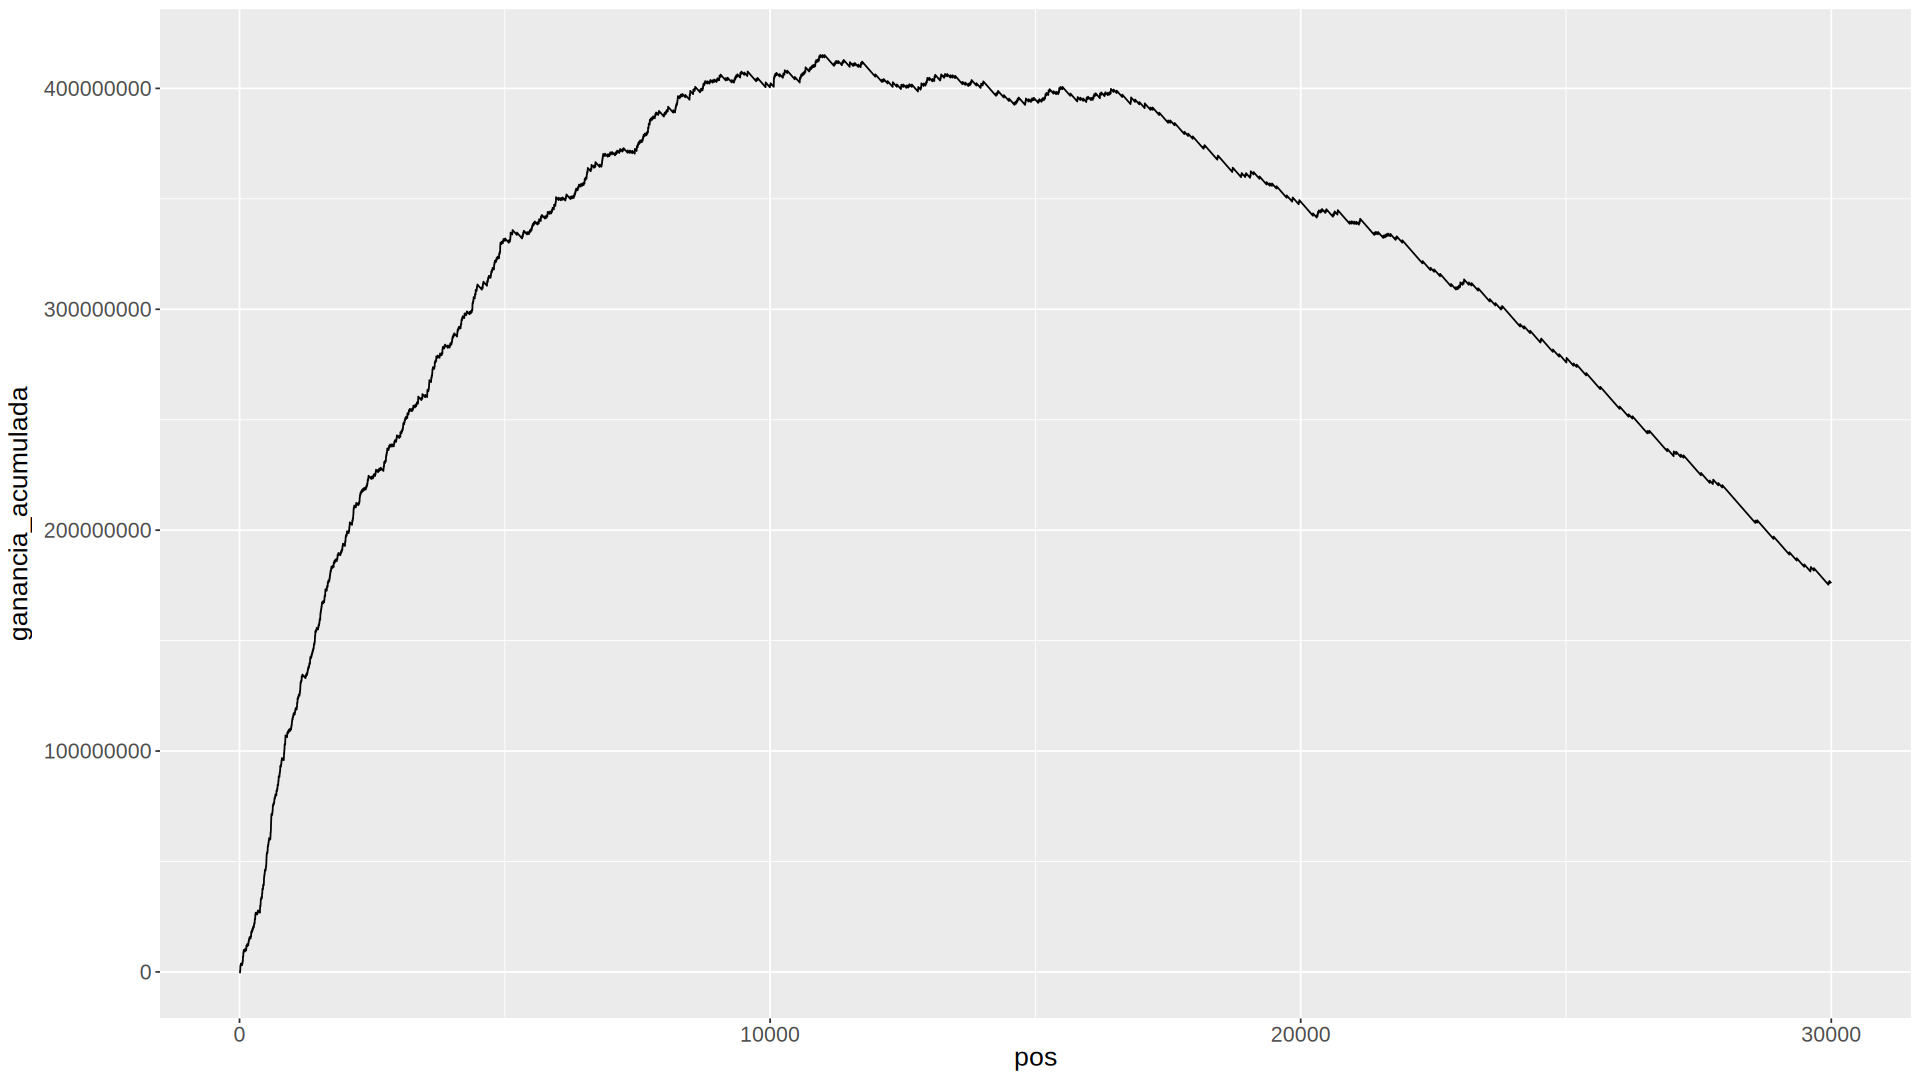

In [133]:
# observamos la curva de ganancia
gra <- ggplot(
           data= tb_prediccion_sub[pos <= amostrar],
           aes( x= pos, y= ganancia_acumulada)
             ) + geom_line()

gra <- gra + theme(text = element_text(size = 16))

options(repr.plot.width=16, repr.plot.height=9)
print( gra )

In [134]:
# inicilizo el dataset  drealidad
drealidad <- realidad_inicializar( dfuture, PARAM)

In [135]:
# genero archivos con los  "envios" mejores

# ordeno por probabilidad descendente
setorder(tb_prediccion, -prob)

for (envios in PARAM$cortes) {

  tb_prediccion[, Predicted := 0L] # seteo inicial a 0
  tb_prediccion[1:envios, Predicted := 1L] # marco los primeros

  res <- realidad_evaluar( drealidad, tb_prediccion)

  options(scipen = 999)
  cat( "Envios=", envios, "\t",
    " TOTAL=", res$total,
    "  Public=", res$public,
    " Private=", res$private,
    "\n",
    sep= ""
  )

}

Envios=4000	 TOTAL=228800000  Public=249241667 Private=220039286
Envios=4500	 TOTAL=249150000  Public=260058333 Private=244475000
Envios=5000	 TOTAL=262900000  Public=260791667 Private=263803571
Envios=5500	 TOTAL=272250000  Public=265283333 Private=275235714
Envios=6000	 TOTAL=287100000  Public=267666667 Private=295428571
Envios=6500	 TOTAL=311850000  Public=288475000 Private=321867857
Envios=7000	 TOTAL=317900000  Public=298191667 Private=326346429
Envios=7500	 TOTAL=331650000  Public=328350000 Private=333064286
Envios=8000	 TOTAL=344300000  Public=347966667 Private=342728571
Envios=8500	 TOTAL=356950000  Public=355941667 Private=357382143
Envios=9000	 TOTAL=367400000  Public=379225000 Private=362332143
Envios=9500	 TOTAL=374550000  Public=377391667 Private=373332143
Envios=10000	 TOTAL=375100000  Public=378491667 Private=373646429
Envios=10500	 TOTAL=378950000  Public=376383333 Private=380050000
Envios=11000	 TOTAL=385000000  Public=395358333 Private=380560714
Envios=11500	 TOTAL=38